In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("car_price_prediction_.csv")
data.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


# Step 1 — Data Understanding
 

In [3]:
data.shape

(2500, 10)

In [4]:
data.size

25000

In [5]:
data.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [7]:
data.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [8]:
data.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

# Step 2 — EDA

In [12]:
data.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

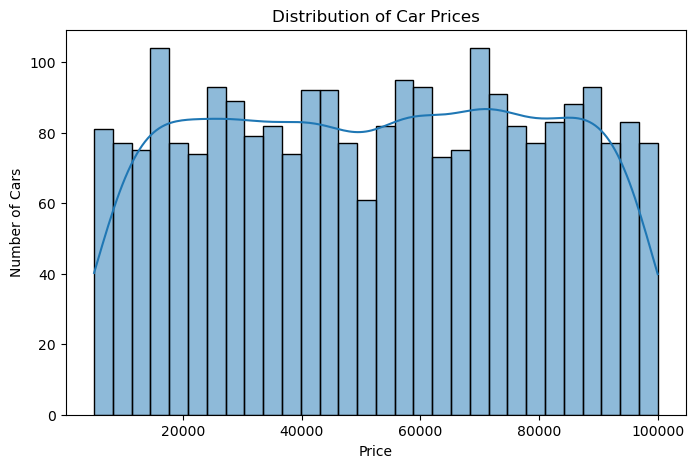

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(data['Price'], bins=30, kde=True)

plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.show()

<h2>This shows how the car prices are distributed.</h2>

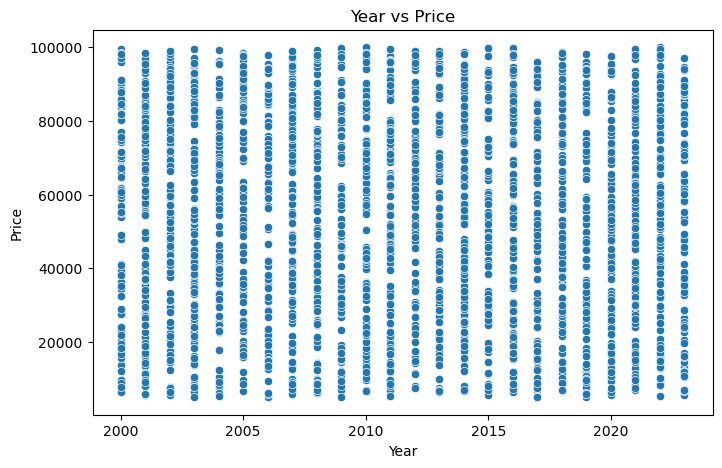

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=data, x='Year', y='Price')

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Year vs Price')
plt.show()

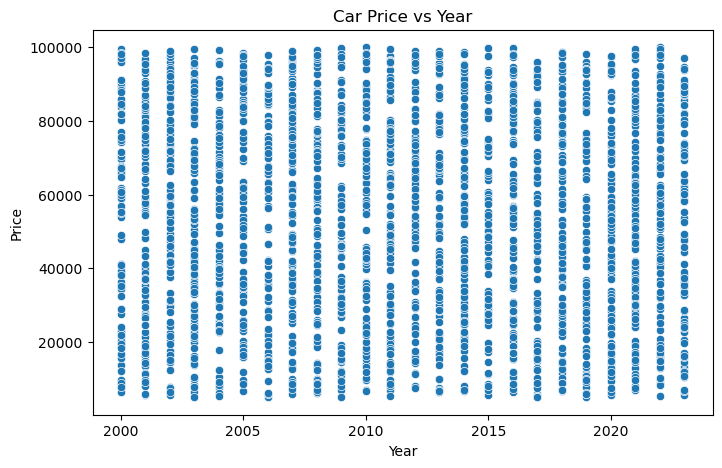

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=data, x='Year', y='Price')

plt.title('Car Price vs Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

<h3>This boxplot compares the distribution of car prices for different fuel types. It helps identify differences in car prices across fuel categories</h3>

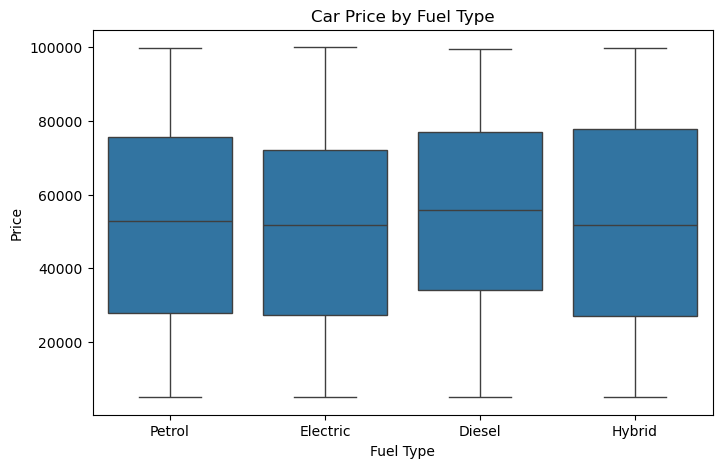

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data, x='Fuel Type', y='Price')

plt.title('Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

<h3>This boxplot compares car prices across different transmission types. It helps understand how transmission type is associated with the distribution of car prices.</h3>

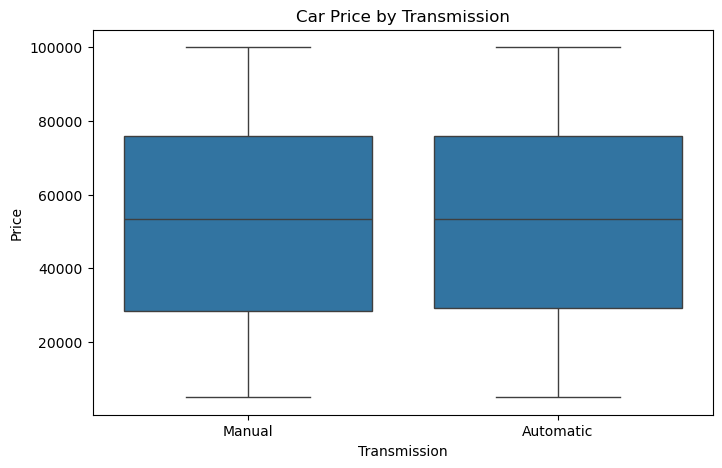

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data, x='Transmission', y='Price')

plt.title('Car Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.show()

<h3>This heatmap shows the correlation between the numerical features in the dataset. It helps identify which features have a strong or weak relationship with car price.</h3

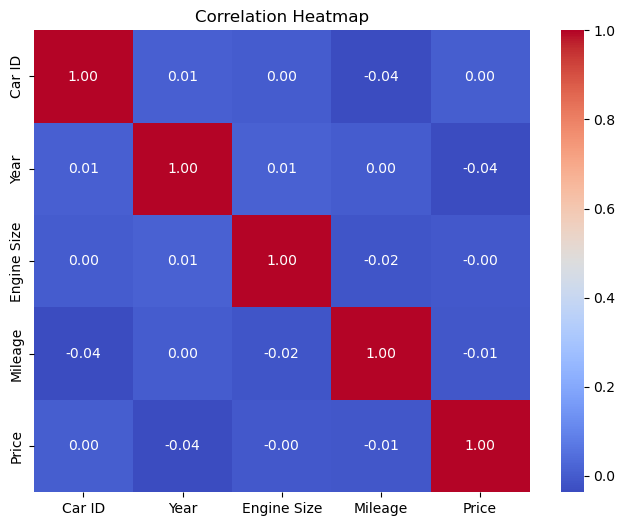

In [18]:
plt.figure(figsize=(8,6))

numeric_df = data.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

<h2>This chart shows the top 15 car models based on their average selling price. It helps identify which car models have higher average prices in the dataset.</h2>

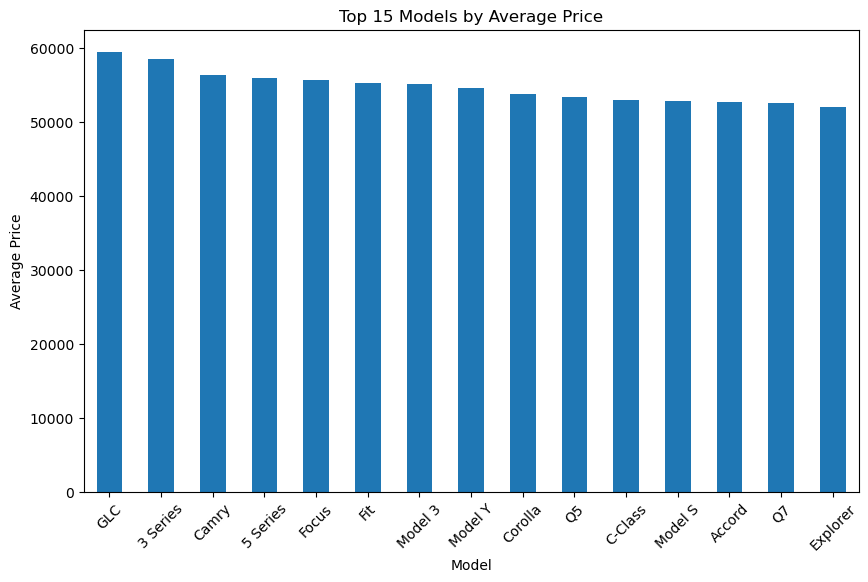

In [19]:
model_price = data.groupby('Model')['Price'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

model_price.plot(kind='bar')

plt.title('Top 15 Models by Average Price')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

<h3>This boxplot shows the distribution of car prices across different fuel types. It helps compare the price ranges and identify differences in prices among fuel categories.</h3>

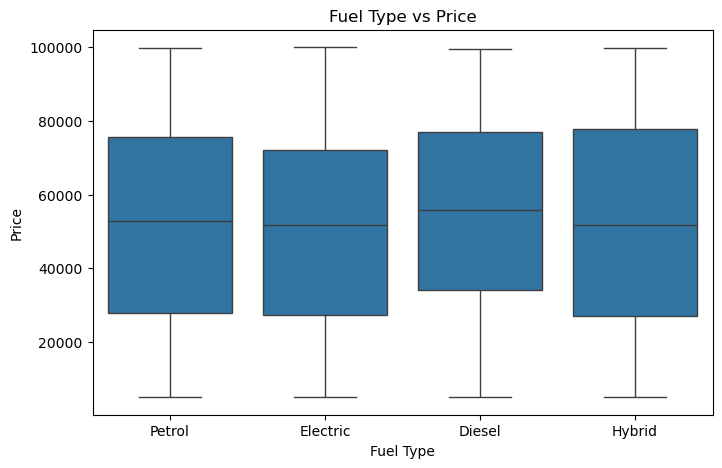

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Fuel Type', y='Price', data=data)
plt.title('Fuel Type vs Price')
plt.show()

# Handle Categorical Columns

In [20]:
data.select_dtypes(include='object').columns

Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')

# Convert Categorical Data into Numerical Data

# Use One-Hot Encoding

In [21]:
data=pd.get_dummies(
    data,columns=['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'],drop_first=True
)

In [22]:
data.head()

,Car ID,Year,Engine Size,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,1,2016,2.3,114832,26613.92,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
1,2,2018,4.4,143190,14679.61,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,2013,4.5,181601,44402.61,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2011,4.1,68682,86374.33,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,5,2009,2.6,223009,73577.10,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car ID               2500 non-null   int64  
 1   Year                 2500 non-null   int64  
 2   Engine Size          2500 non-null   float64
 3   Mileage              2500 non-null   int64  
 4   Price                2500 non-null   float64
 5   Brand_BMW            2500 non-null   bool   
 6   Brand_Ford           2500 non-null   bool   
 7   Brand_Honda          2500 non-null   bool   
 8   Brand_Mercedes       2500 non-null   bool   
 9   Brand_Tesla          2500 non-null   bool   
 10  Brand_Toyota         2500 non-null   bool   
 11  Fuel Type_Electric   2500 non-null   bool   
 12  Fuel Type_Hybrid     2500 non-null   bool   
 13  Fuel Type_Petrol     2500 non-null   bool   
 14  Transmission_Manual  2500 non-null   bool   
 15  Condition_New        2500 non-null   b

In [25]:
numeric_columns = data.select_dtypes(include=np.number).columns

numeric_columns

Index(['Car ID', 'Year', 'Engine Size', 'Mileage', 'Price'], dtype='object')

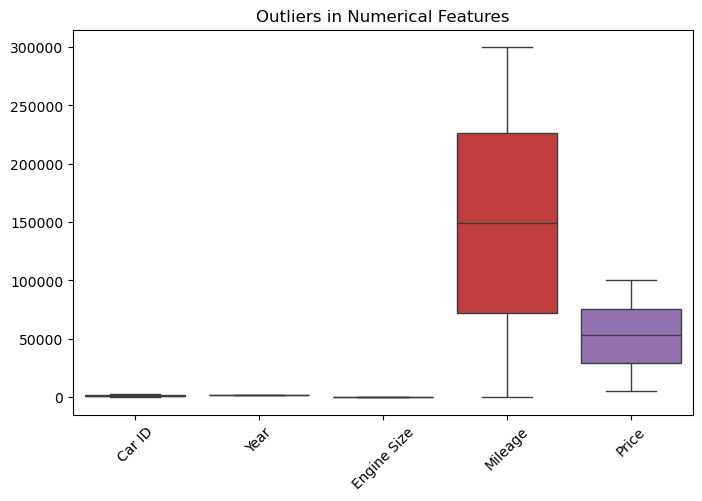

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data[numeric_columns])

plt.xticks(rotation=45)
plt.title('Outliers in Numerical Features')
plt.show()

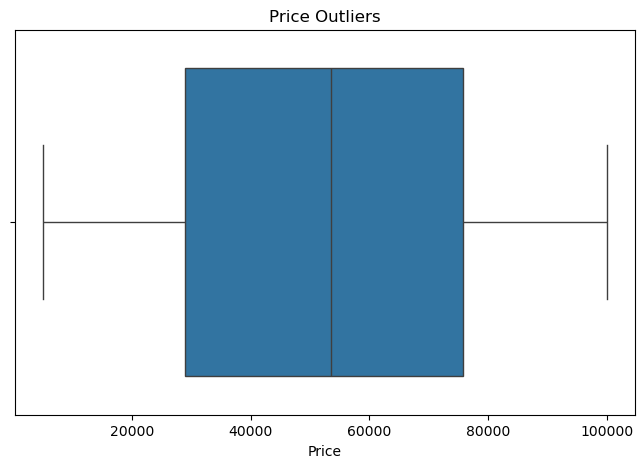

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=data['Price'])

plt.title('Price Outliers')
plt.show()

In [29]:
X=data.drop("Price",axis=1)
X.head()

,Car ID,Year,Engine Size,Mileage,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,1,2016,2.3,114832,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
1,2,2018,4.4,143190,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,2013,4.5,181601,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2011,4.1,68682,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
4,5,2009,2.6,223009,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [31]:
y=data["Price"]
y.head()

0    26613.92
1    14679.61
2    44402.61
3    86374.33
4    73577.10
Name: Price, dtype: float64

# Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [33]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2000, 43)
X_test: (500, 43)
y_train: (2000,)
y_test: (500,)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Target training data:", y_train.shape)
print("Target testing data:", y_test.shape)

Training data: (2000, 43)
Testing data: (500, 43)
Target training data: (2000,)
Target testing data: (500,)


In [44]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


In [41]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [45]:
from sklearn.metrics import r2_score

lr_r2 = r2_score(y_test, y_pred_lr)
dt_r2 = r2_score(y_test, y_pred_dt)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Linear Regression R²:", lr_r2)
print("Decision Tree R²:", dt_r2)
print("Random Forest R²:", rf_r2)

Linear Regression R²: -0.02016965818012606
Decision Tree R²: -0.9285242790676209
Random Forest R²: -0.042742352177170595


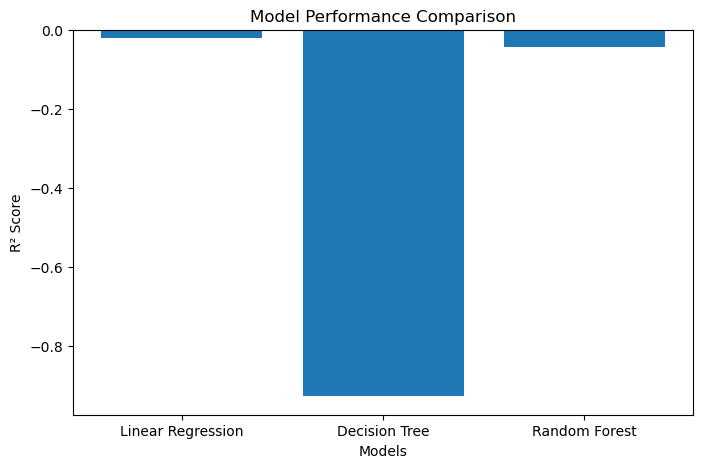

In [46]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [lr_r2, dt_r2, rf_r2]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_scores)

plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison')

plt.show()

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Linear Regression
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)

# Decision Tree
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)

# Random Forest
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

print("Linear Regression")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)

print("\nDecision Tree")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)

print("\nRandom Forest")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)

Linear Regression
MAE: 23875.794465684234
MSE: 772832924.0492985
RMSE: 27799.87273440831

Decision Tree
MAE: 31052.17888
MSE: 1460959993.998114
RMSE: 38222.50638037901

Random Forest
MAE: 24314.5340382
MSE: 789932943.6053847
RMSE: 28105.745740068607


In [49]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [lr_r2, dt_r2, rf_r2],
    'MAE': [lr_mae, dt_mae, rf_mae],
    'MSE': [lr_mse, dt_mse, rf_mse],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse]
})

results

,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,-0.020170,23875.794466,7.728329e+08,27799.872734
1,Decision Tree,-0.928524,31052.178880,1.460960e+09,38222.506380
2,Random Forest,-0.042742,24314.534038,7.899329e+08,28105.745740


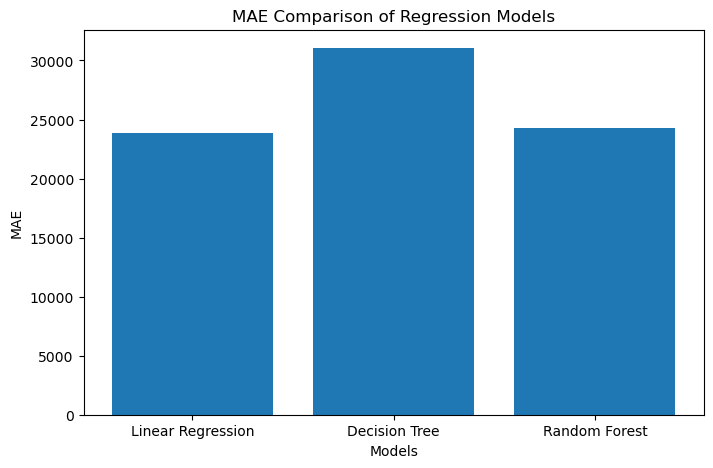

In [50]:
plt.figure(figsize=(8, 5))

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
mae_values = [lr_mae, dt_mae, rf_mae]

plt.bar(models, mae_values)

plt.xlabel('Models')
plt.ylabel('MAE')
plt.title('MAE Comparison of Regression Models')

plt.show()

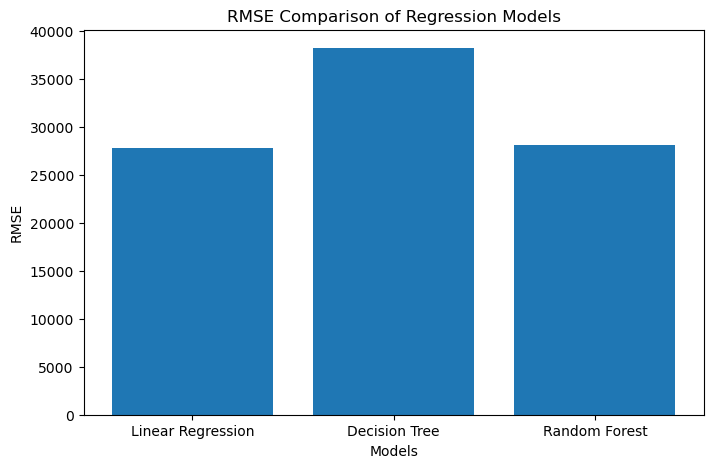

In [51]:
plt.figure(figsize=(8, 5))

rmse_values = [lr_rmse, dt_rmse, rf_rmse]

plt.bar(models, rmse_values)

plt.xlabel('Models')
plt.ylabel('RMSE')
plt.title('RMSE Comparison of Regression Models')

plt.show()

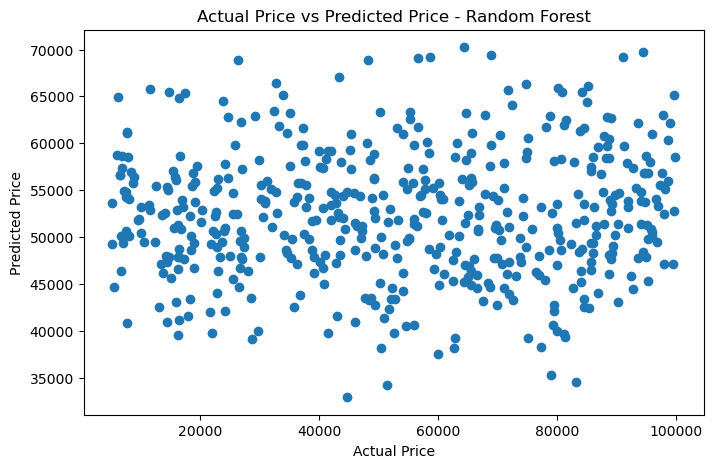

In [52]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price vs Predicted Price - Random Forest')

plt.show()

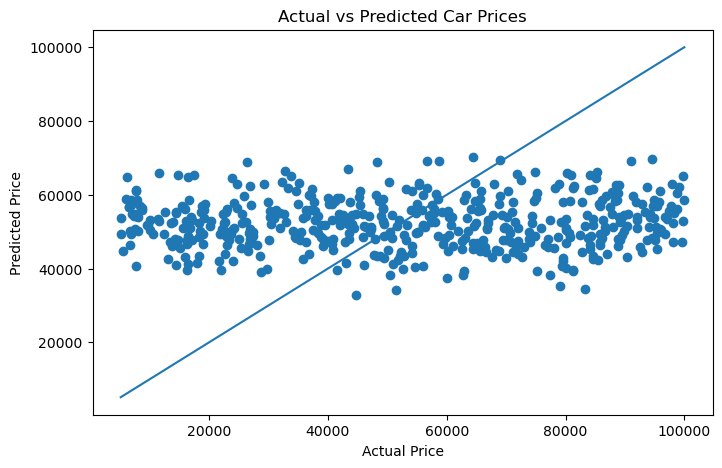

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

In [54]:
results


,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,-0.020170,23875.794466,7.728329e+08,27799.872734
1,Decision Tree,-0.928524,31052.178880,1.460960e+09,38222.506380
2,Random Forest,-0.042742,24314.534038,7.899329e+08,28105.745740


In [55]:
best_model = results.loc[results['R2 Score'].idxmax()]

print("Best Model:")
print(best_model)


Best Model:
Model       Linear Regression
R2 Score             -0.02017
MAE              23875.794466
MSE          772832924.049299
RMSE             27799.872734
Name: 0, dtype: object


In [56]:
import joblib

joblib.dump(lr_model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

In [57]:
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']